<a href="https://colab.research.google.com/github/kalpana222/CodeAlpha_Credit_Scoring_Model/blob/main/Credit__Scoring__Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 💳 Credit Scoring Model
CodeAlpha Machine Learning Internship

Name: Kalpana

Domain: Machine Learning

Project 1: Credit Scoring Model

## 📌 Problem Statement

Credit scoring is a crucial process used by financial institutions to determine whether an individual is likely to repay a loan. By analyzing an applicant's financial history and personal information, machine learning models can predict creditworthiness and support better lending decisions.

The objective of this project is to build a Credit Scoring Model using classification algorithms. The project includes data preprocessing, exploratory data analysis, feature engineering, model training, and evaluation to identify the best-performing model for predicting credit risk.

### 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

###2. Load Dataset

In [2]:
df = pd.read_csv("german_credit_data.csv")
df.head()

,laufkont,laufzeit,moral,verw,hoehe,sparkont,beszeit,rate,famges,buerge,...,verm,alter,weitkred,wohn,bishkred,beruf,pers,telef,gastarb,kredit
0,1,18,4,2,1049,1,2,4,2,1,...,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,...,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,...,1,23,3,1,1,2,2,1,2,1
3,1,12,4,0,2122,1,3,3,3,1,...,1,39,3,1,2,2,1,1,1,1
4,1,12,4,0,2171,1,3,4,3,1,...,2,38,1,2,2,2,2,1,1,1


###3. Rename Columns

The original dataset contains German column names. For better readability and understanding, the column names are renamed to meaningful English names. This improves code readability, visualization labels, and overall project presentation without modifying the underlying data.

In [3]:
df.rename(columns={
    'laufkont': 'Checking_Account',
    'laufzeit': 'Duration',
    'moral': 'Credit_History',
    'verw': 'Purpose',
    'hoehe': 'Credit_Amount',
    'sparkont': 'Savings_Account',
    'beszeit': 'Employment_Duration',
    'rate': 'Installment_Rate',
    'famges': 'Personal_Status_Sex',
    'buerge': 'Other_Debtors',
    'wohnzeit': 'Present_Residence',
    'verm': 'Property',
    'alter': 'Age',
    'weitkred': 'Other_Installment_Plans',
    'wohn': 'Housing',
    'bishkred': 'Existing_Credits',
    'beruf': 'Job',
    'pers': 'Number_of_Dependents',
    'telef': 'Telephone',
    'gastarb': 'Foreign_Worker',
    'kredit': 'Credit_Risk'
}, inplace=True)
df.head()

,Checking_Account,Duration,Credit_History,Purpose,Credit_Amount,Savings_Account,Employment_Duration,Installment_Rate,Personal_Status_Sex,Other_Debtors,...,Property,Age,Other_Installment_Plans,Housing,Existing_Credits,Job,Number_of_Dependents,Telephone,Foreign_Worker,Credit_Risk
0,1,18,4,2,1049,1,2,4,2,1,...,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,...,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,...,1,23,3,1,1,2,2,1,2,1
3,1,12,4,0,2122,1,3,3,3,1,...,1,39,3,1,2,2,1,1,1,1
4,1,12,4,0,2171,1,3,4,3,1,...,2,38,1,2,2,2,2,1,1,1


###4. Data Understanding

In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (1000, 21)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Checking_Account         1000 non-null   int64
 1   Duration                 1000 non-null   int64
 2   Credit_History           1000 non-null   int64
 3   Purpose                  1000 non-null   int64
 4   Credit_Amount            1000 non-null   int64
 5   Savings_Account          1000 non-null   int64
 6   Employment_Duration      1000 non-null   int64
 7   Installment_Rate         1000 non-null   int64
 8   Personal_Status_Sex      1000 non-null   int64
 9   Other_Debtors            1000 non-null   int64
 10  Present_Residence        1000 non-null   int64
 11  Property                 1000 non-null   int64
 12  Age                      1000 non-null   int64
 13  Other_Installment_Plans  1000 non-null   int64
 14  Housing                  1000 non-null   int64
 15  Exist

In [6]:
df.columns

Index(['Checking_Account', 'Duration', 'Credit_History', 'Purpose',
       'Credit_Amount', 'Savings_Account', 'Employment_Duration',
       'Installment_Rate', 'Personal_Status_Sex', 'Other_Debtors',
       'Present_Residence', 'Property', 'Age', 'Other_Installment_Plans',
       'Housing', 'Existing_Credits', 'Job', 'Number_of_Dependents',
       'Telephone', 'Foreign_Worker', 'Credit_Risk'],
      dtype='object')

In [7]:
df.isnull().sum()

,0
Checking_Account,0
Duration,0
Credit_History,0
Purpose,0
Credit_Amount,0
Savings_Account,0
Employment_Duration,0
Installment_Rate,0
Personal_Status_Sex,0
Other_Debtors,0


In [8]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Checking_Account,1000.0,2.577,1.257638,1.0,1.0,2.0,4.00,4.0
Duration,1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0
Credit_History,1000.0,2.545,1.083120,0.0,2.0,2.0,4.00,4.0
Purpose,1000.0,2.828,2.744439,0.0,1.0,2.0,3.00,10.0
Credit_Amount,1000.0,3271.248,2822.751760,250.0,1365.5,2319.5,3972.25,18424.0
Savings_Account,1000.0,2.105,1.580023,1.0,1.0,1.0,3.00,5.0
Employment_Duration,1000.0,3.384,1.208306,1.0,3.0,3.0,5.00,5.0
Installment_Rate,1000.0,2.973,1.118715,1.0,2.0,3.0,4.00,4.0
Personal_Status_Sex,1000.0,2.682,0.708080,1.0,2.0,3.0,3.00,4.0
Other_Debtors,1000.0,1.145,0.477706,1.0,1.0,1.0,1.00,3.0


In [10]:
df.nunique()

,0
Checking_Account,4
Duration,33
Credit_History,5
Purpose,10
Credit_Amount,923
Savings_Account,5
Employment_Duration,5
Installment_Rate,4
Personal_Status_Sex,4
Other_Debtors,3


### 5. Exploratory Data Analysis

####Target Variable Distribution
This plot shows the distribution of the target variable (Credit Risk). It helps determine whether the dataset is balanced or imbalanced, which is important when selecting evaluation metrics and training machine learning models.

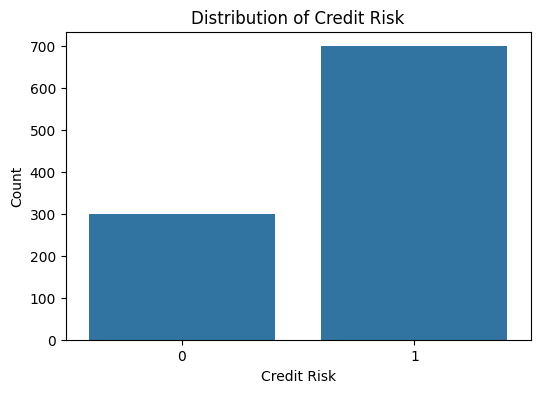

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x='Credit_Risk', data=df)
plt.title("Distribution of Credit Risk")
plt.xlabel("Credit Risk")
plt.ylabel("Count")
plt.show()

####Age Distribution
This histogram illustrates the distribution of applicants' ages. It helps identify the most common age range and any potential skewness in the data.

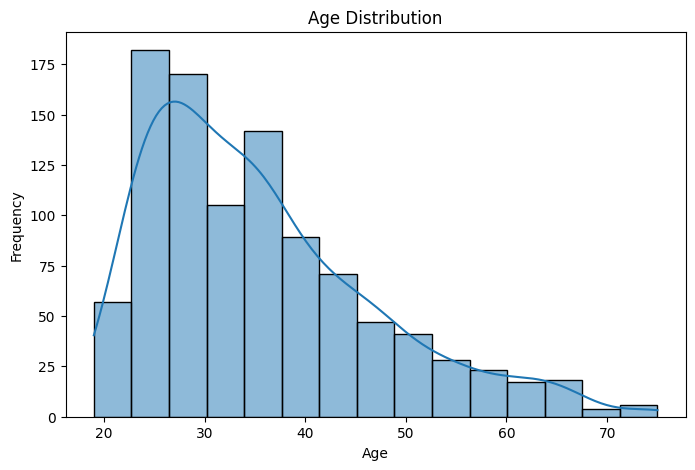

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=15, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

####Credit Amount Distribution
This visualization shows how credit amounts are distributed among applicants. It helps identify whether most loans are small, large, or spread across a wide range of values.

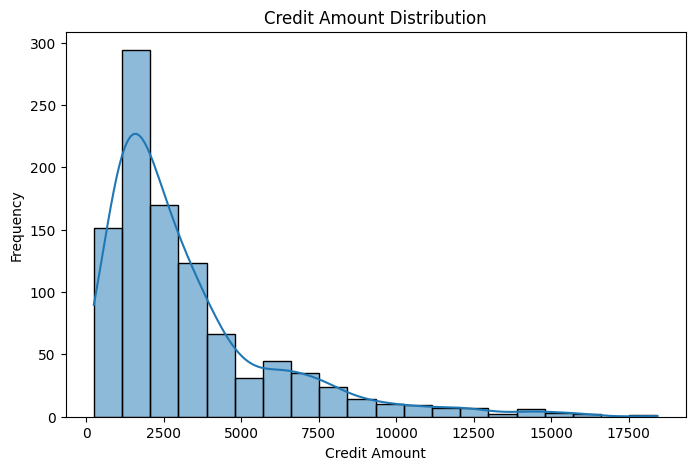

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df['Credit_Amount'], bins=20, kde=True)
plt.title("Credit Amount Distribution")
plt.xlabel("Credit Amount")
plt.ylabel("Frequency")
plt.show()

####Loan Duration Distribution
This plot shows the distribution of loan durations. It helps identify the most common repayment periods among applicants.

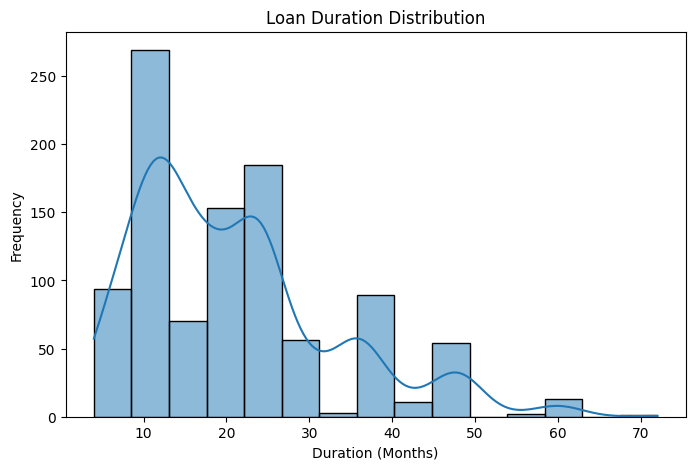

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df['Duration'], bins=15, kde=True)
plt.title("Loan Duration Distribution")
plt.xlabel("Duration (Months)")
plt.ylabel("Frequency")
plt.show()

####Correlation Heatmap
The correlation heatmap illustrates the relationships between variables. It helps identify strong positive or negative correlations that may influence model performance.

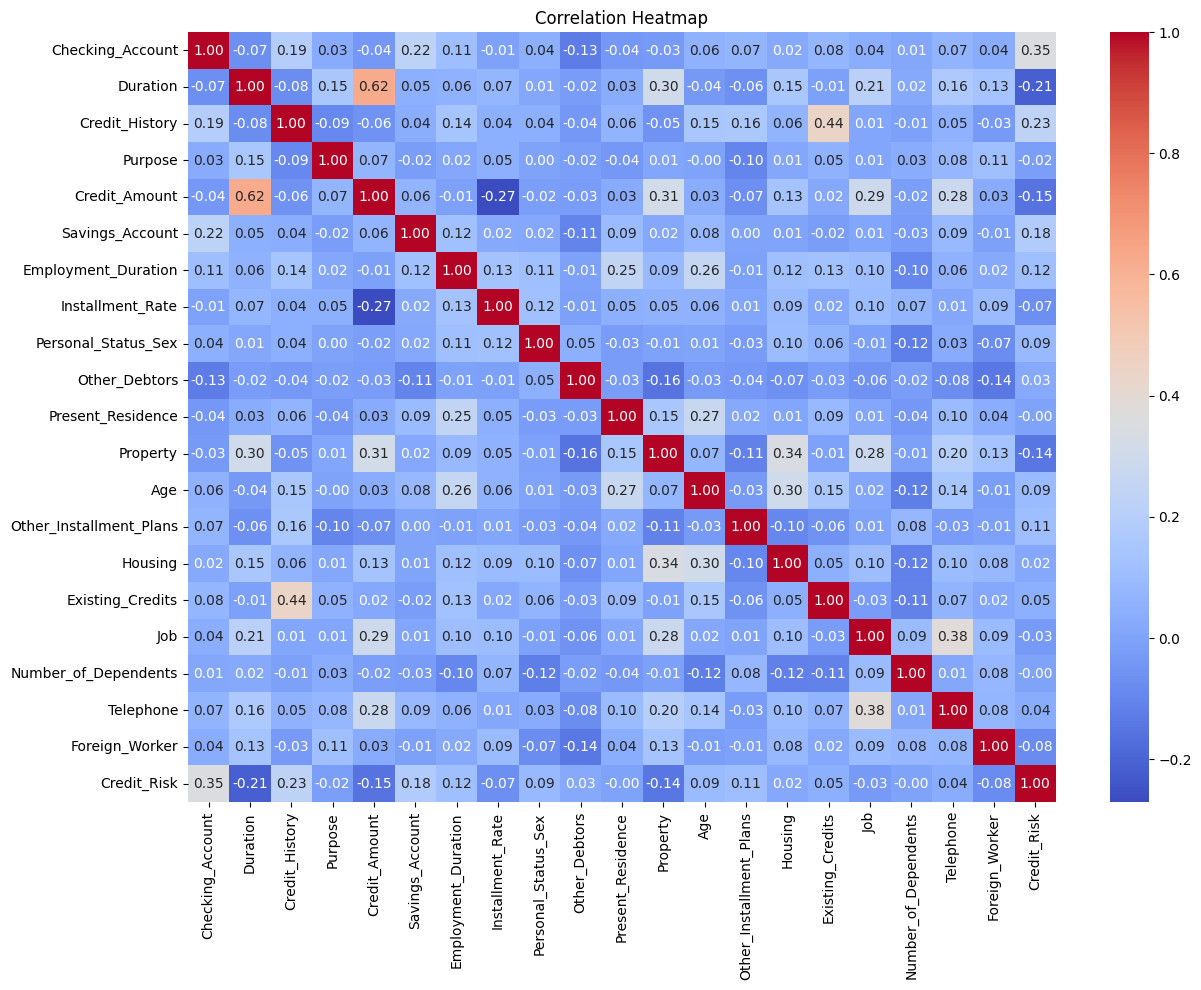

In [15]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

####Credit Amount vs Credit Risk

This box plot compares the distribution of credit amounts across different credit risk categories. It helps identify whether applicants with different credit risk levels tend to request different loan amounts and highlights the presence of outliers.

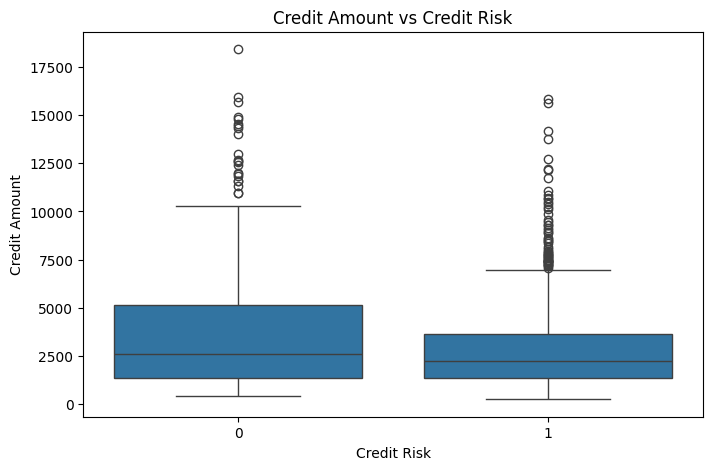

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Credit_Risk', y='Credit_Amount', data=df)
plt.title("Credit Amount vs Credit Risk")
plt.xlabel("Credit Risk")
plt.ylabel("Credit Amount")
plt.show()

####Age vs Credit Risk

This visualization compares the age distribution of applicants across different credit risk categories. It helps determine whether age has any noticeable relationship with an applicant's creditworthiness.

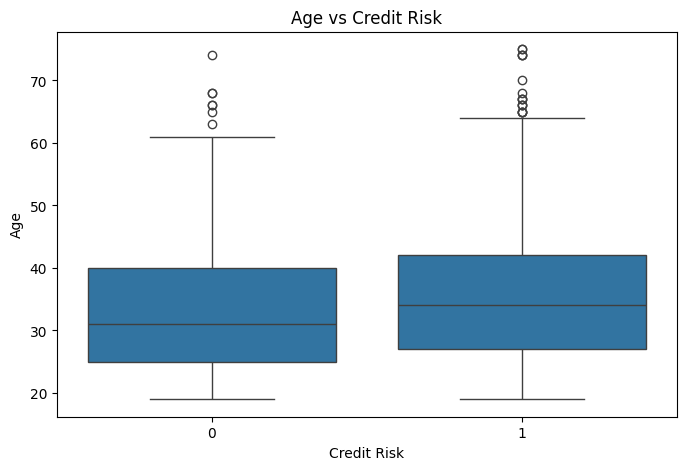

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Credit_Risk', y='Age', data=df)
plt.title("Age vs Credit Risk")
plt.xlabel("Credit Risk")
plt.ylabel("Age")
plt.show()

####Loan Duration vs Credit Risk

This box plot illustrates the relationship between loan duration and credit risk. It helps analyze whether applicants with different loan repayment periods exhibit different levels of credit risk.

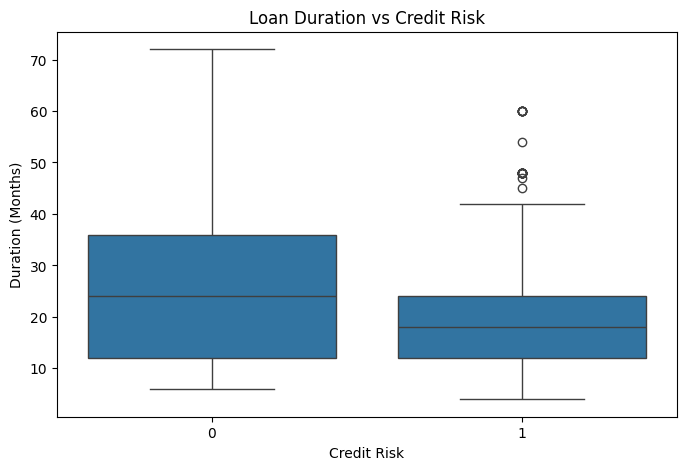

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Credit_Risk', y='Duration', data=df)
plt.title("Loan Duration vs Credit Risk")
plt.xlabel("Credit Risk")
plt.ylabel("Duration (Months)")
plt.show()

####Credit Risk by Age Group

This stacked histogram displays the distribution of applicants' ages across different credit risk categories. It helps visualize how credit risk is distributed among various age groups.

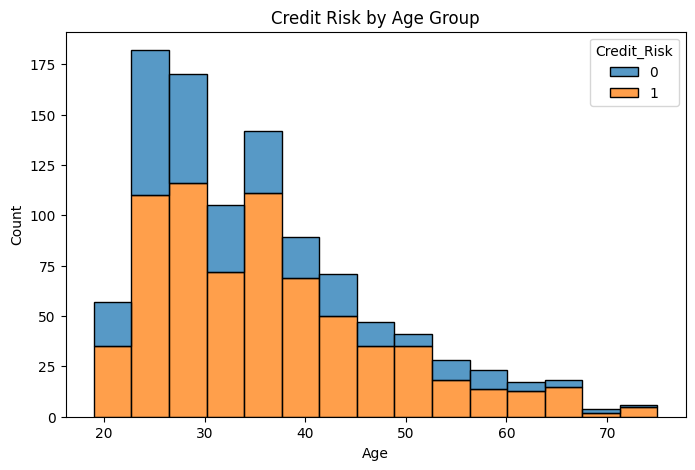

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Age', hue='Credit_Risk', bins=15, multiple='stack')
plt.title("Credit Risk by Age Group")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

###6. Feature Engineering

To enhance the predictive capability of the model, additional financial features were created from the existing dataset.

- **Monthly_Loan_Burden**: Represents the average loan amount to be repaid per month (`Credit_Amount / Duration`).
- **Credit_per_Existing_Loan**: Represents the ratio of the requested credit amount to the number of existing credits.


In [20]:
# Monthly Loan Burden
df['Monthly_Loan_Burden'] = df['Credit_Amount'] / df['Duration']

In [21]:
df['Credit_per_Existing_Loan'] = (
    df['Credit_Amount'] /
    (df['Existing_Credits'] + 1)
)

###7. Data Preprocessing

####Feature selection

In [22]:
X = df.drop('Credit_Risk', axis=1)
y = df['Credit_Risk']

print("Feature Matrix Shape:", X.shape)
print("Target Variable Shape:", y.shape)

Feature Matrix Shape: (1000, 22)
Target Variable Shape: (1000,)


In [23]:
print("Features:")
X.head()

Features:


,Checking_Account,Duration,Credit_History,Purpose,Credit_Amount,Savings_Account,Employment_Duration,Installment_Rate,Personal_Status_Sex,Other_Debtors,...,Age,Other_Installment_Plans,Housing,Existing_Credits,Job,Number_of_Dependents,Telephone,Foreign_Worker,Monthly_Loan_Burden,Credit_per_Existing_Loan
0,1,18,4,2,1049,1,2,4,2,1,...,21,3,1,1,3,2,1,2,58.277778,524.500000
1,1,9,4,0,2799,1,3,2,3,1,...,36,3,1,2,3,1,1,2,311.000000,933.000000
2,2,12,2,9,841,2,4,2,2,1,...,23,3,1,1,2,2,1,2,70.083333,420.500000
3,1,12,4,0,2122,1,3,3,3,1,...,39,3,1,2,2,1,1,1,176.833333,707.333333
4,1,12,4,0,2171,1,3,4,3,1,...,38,1,2,2,2,2,1,1,180.916667,723.666667


In [24]:
print("Target:")
y.head()

Target:


,Credit_Risk
0,1
1,1
2,1
3,1
4,1


####Train-Test Split

In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (800, 22)
Testing Features  : (200, 22)
Training Labels   : (800,)
Testing Labels    : (200,)


####Feature Scaling

In [26]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


###8. Model Building

In this section, three machine learning classification algorithms are trained and evaluated to predict an applicant's credit risk. The models selected for this project are:

- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier

These models are compared using various evaluation metrics to determine the best-performing classifier.

####Logistic Regression



In [27]:
# Train the Model
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(random_state=42)
log_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [28]:
# Make predictions
y_pred_log = log_model.predict(X_test_scaled)

In [29]:
#  Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
print("Accuracy :", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall   :", recall_score(y_test, y_pred_log))
print("F1 Score :", f1_score(y_test, y_pred_log))
print("ROC-AUC  :", roc_auc_score(y_test, y_pred_log))

Accuracy : 0.76
Precision: 0.7884615384615384
Recall   : 0.8913043478260869
F1 Score : 0.8367346938775511
ROC-AUC  : 0.679523141654979


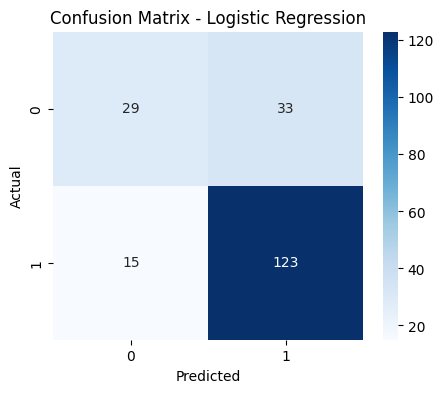

In [30]:
# Confusion Matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [31]:
# Classification Report
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.66      0.47      0.55        62
           1       0.79      0.89      0.84       138

    accuracy                           0.76       200
   macro avg       0.72      0.68      0.69       200
weighted avg       0.75      0.76      0.75       200



####Decision Tree Classifier


In [32]:
# Train the Model
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [33]:
# Make predictions
y_pred_dt = dt_model.predict(X_test)

In [34]:
#  Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))
print("ROC-AUC  :", roc_auc_score(y_test, y_pred_dt))

Accuracy : 0.7
Precision: 0.8046875
Recall   : 0.7463768115942029
F1 Score : 0.7744360902255639
ROC-AUC  : 0.671575502571295


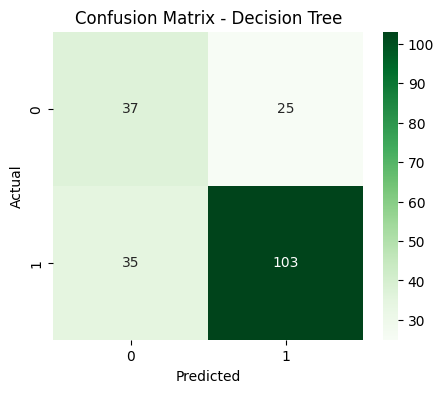

In [35]:
# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(5,4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens')

plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [36]:
# Classification Report
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.51      0.60      0.55        62
           1       0.80      0.75      0.77       138

    accuracy                           0.70       200
   macro avg       0.66      0.67      0.66       200
weighted avg       0.71      0.70      0.71       200



####Random Forest Classifier

In [37]:
# Train the Model
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [38]:
# Make predictions
y_pred_rf = rf_model.predict(X_test)

In [39]:
#  Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_pred_rf))

Accuracy : 0.77
Precision: 0.8066666666666666
Recall   : 0.8768115942028986
F1 Score : 0.8402777777777778
ROC-AUC  : 0.7045348293595137


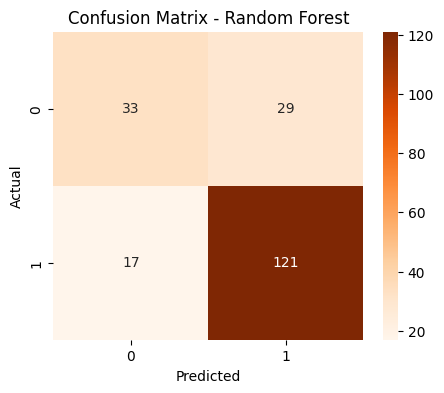

In [40]:
# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges')

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [41]:
# Classification Report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.66      0.53      0.59        62
           1       0.81      0.88      0.84       138

    accuracy                           0.77       200
   macro avg       0.73      0.70      0.71       200
weighted avg       0.76      0.77      0.76       200



###9. Model Comparison

In [42]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],

    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf)
    ],

    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ],

    "ROC-AUC": [
        roc_auc_score(y_test, y_pred_log),
        roc_auc_score(y_test, y_pred_dt),
        roc_auc_score(y_test, y_pred_rf)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.76,0.788462,0.891304,0.836735,0.679523
1,Decision Tree,0.70,0.804688,0.746377,0.774436,0.671576
2,Random Forest,0.77,0.806667,0.876812,0.840278,0.704535


In [43]:
best_model = comparison.loc[
    comparison["Accuracy"].idxmax(),
    "Model"
]
print("Best Performing Model :", best_model)

Best Performing Model : Random Forest


###10. Creditworthiness Prediction

After selecting the best-performing model, it can be used to predict the creditworthiness of a new loan applicant based on their financial information.

The following example demonstrates how the trained Random Forest model predicts whether an applicant has good or bad credit risk.

In [44]:
# Select one applicant
sample = X.iloc[[0]]

# Display applicant details
print("Applicant Information")
display(sample)

# Predict credit risk
prediction = rf_model.predict(sample)

print("\nPredicted Credit Risk:", prediction[0])

if prediction[0] == 1:
    print("The applicant is predicted to have GOOD creditworthiness.")
else:
    print("The applicant is predicted to have POOR creditworthiness.")

Applicant Information


,Checking_Account,Duration,Credit_History,Purpose,Credit_Amount,Savings_Account,Employment_Duration,Installment_Rate,Personal_Status_Sex,Other_Debtors,...,Age,Other_Installment_Plans,Housing,Existing_Credits,Job,Number_of_Dependents,Telephone,Foreign_Worker,Monthly_Loan_Burden,Credit_per_Existing_Loan
0,1,18,4,2,1049,1,2,4,2,1,...,21,3,1,1,3,2,1,2,58.277778,524.5



Predicted Credit Risk: 1
The applicant is predicted to have GOOD creditworthiness.


#### Prediction Interpretation

- **1** → Good Creditworthiness
- **0** → Poor Creditworthiness

The trained Random Forest model predicts the credit risk of a new applicant based on their financial information.

## 🎯 Conclusion

In this project, a **Credit Scoring Model** was developed to predict an individual's creditworthiness using historical financial data. The dataset was first explored through data understanding and exploratory data analysis (EDA) to identify important patterns and relationships among the features.

To improve the model's predictive capability, **feature engineering** was performed by creating meaningful financial features such as **Monthly Loan Burden** and **Credit per Existing Loan**. The data was then preprocessed using feature selection, train-test splitting, and feature scaling where required.

Three machine learning classification algorithms—**Logistic Regression**, **Decision Tree Classifier**, and **Random Forest Classifier**—were trained and evaluated using **Accuracy, Precision, Recall, F1-Score, ROC-AUC Score, Confusion Matrix,** and **Classification Report**.

After comparing the performance of all models, the **Random Forest Classifier** achieved the best overall results and was selected as the final model. Finally, the trained model was used to predict the creditworthiness of a sample applicant, demonstrating how machine learning can support financial institutions in making informed and reliable credit approval decisions.

Overall, this project highlights the complete machine learning workflow—from data exploration and feature engineering to model building, evaluation, and real-world prediction—showing the practical application of classification techniques in credit risk assessment.